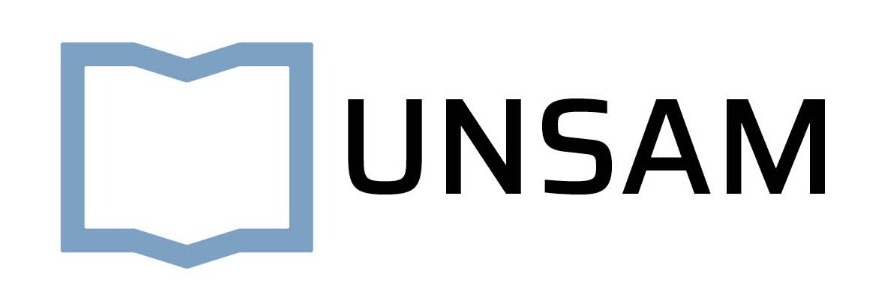

# APS : TS3 Castiñeira 

## Autor: Santiago Castiñeira

## Consigana del TP:
## Tarea semanal - Desparramo espectral

En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la **DFT**: el efecto de **desparramo espectral**.

Luego, realizaremos el siguiente experimento.

Se utilizará una señal senoidal de frecuencia:

$$
f_0 = k_0\frac{f_s}{N} = k_0\Delta f
$$

donde:

$$
\Delta f = \frac{f_s}{N}
$$

La señal tendrá **potencia normalizada**, es decir, energía o varianza unitaria.

---

### a) Efecto de la desintonía

Se analizarán tres valores de $k_0$:

$$
k_0 = \frac{N}{4}
$$

$$
k_0 = \frac{N}{4} + 0.25
$$

$$
k_0 = \frac{N}{4} + 0.5
$$

Notar que a cada senoidal se le agrega una pequeña **desintonía** respecto de $\Delta f$.

Se pide:

- Graficar las tres **densidades espectrales de potencia (PSD)**.
- Comparar los espectros obtenidos.
- Discutir cuál es el efecto de la desintonía sobre el espectro visualizado.

---

### b) Verificación de potencia mediante Parseval

Verificar que la potencia de cada PSD sea unitaria.

Para realizar esta comprobación se puede utilizar la **identidad de Parseval**.

En base a la teoría estudiada, discutir por qué dos señales senoidales cuyas frecuencias difieren solamente unos pocos Hertz pueden presentar espectros considerablemente diferentes al calcular la DFT.

---

### c) Zero Padding

Repetir el experimento utilizando la técnica de **zero padding**.

Esta técnica consiste en agregar ceros al final de la señal para modificar de forma ficticia la representación en frecuencia.

En este caso se agregará un vector de:

$$
9N
$$

ceros al final de la señal original.

De esta manera, la longitud utilizada para calcular la DFT será:

$$
N_{\text{FFT}} = N + 9N = 10N
$$

Repetir las gráficas realizadas en el punto **a)** y discutir los resultados obtenidos.

Comparar los espectros:

- Sin *zero padding*.
- Con *zero padding*.

---

### Bonus 

Calcular la **respuesta en frecuencia** de los sistemas LTI correspondientes a la **TS2**.

## INtroduccion TP: 
En esta tarea se va a analizar el efecto de **desparramo espectral** al calcular la DFT de una señal senoidal.

La idea es observar cómo cambia el espectro cuando la frecuencia de la señal coincide exactamente con uno de los **bins de la DFT** y qué ocurre cuando se encuentra ligeramente desplazada de ellos.

### Punto (a):
Para este punto se sigue trabajando con una base parecida a la utilizada en la **TS2**, tomando:

$$
f_s = 1000\ \text{Hz}
$$

y

$$
N = 1000
$$

muestras.

A partir de estos valores se generan tres señales senoidales de **potencia unitaria**, modificando ligeramente su frecuencia para poder observar cómo afecta esta desintonía al espectro.


Delta f = 1.0 Hz
f1 = 250.0 Hz
f2 = 250.25 Hz
f3 = 250.5 Hz


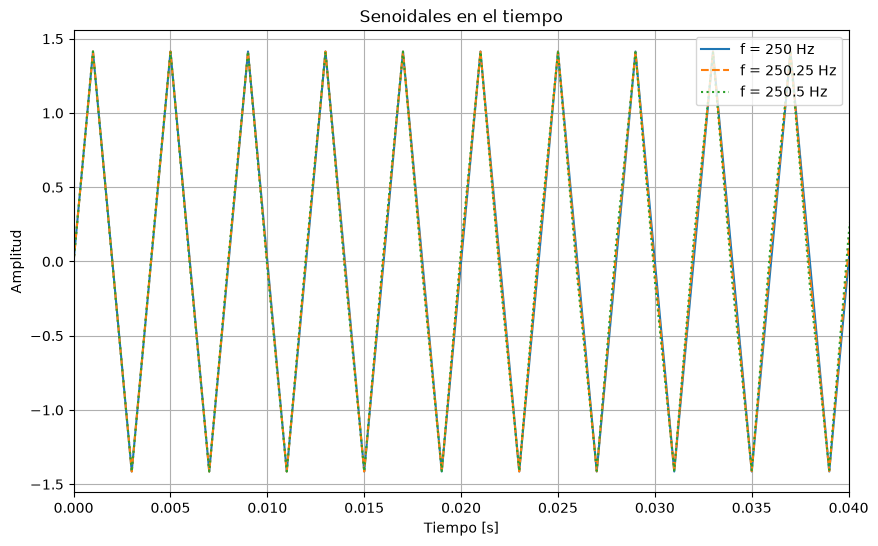

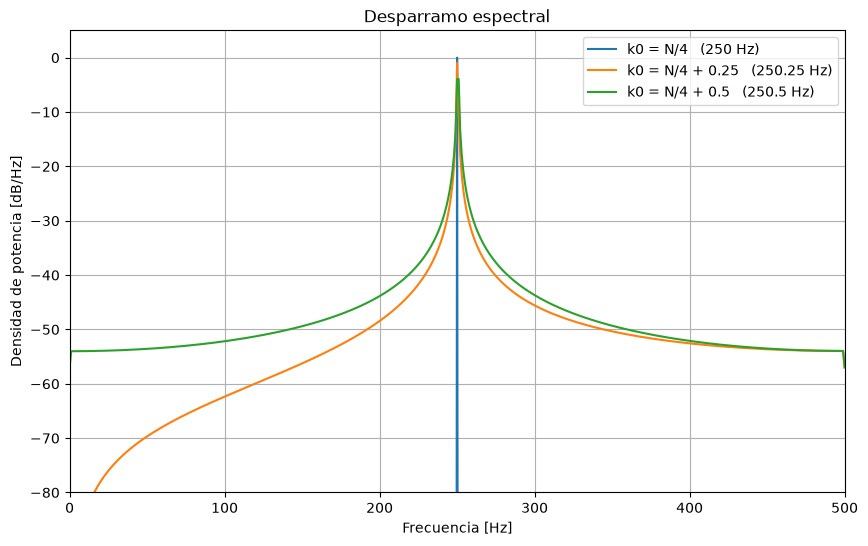

In [2]:

import numpy as np
import matplotlib.pyplot as plt

#%% Parámetros generales

fs = 1000               # frecuencia de muestreo [Hz]
N = 1000                 # cantidad de muestras
ts = 1 / fs               # período de muestreo
tt = np.arange(N) * ts    # vector de tiempo

df = fs / N               # separación entre bins de la DFT

A = np.sqrt(2)            # amplitud para potencia aproximadamente unitaria

#%% Valores de k0

k1 = N/4                 # sin desintonía
k2 = N/4 + 0.25          # desintonía de 0.25 bins
k3 = N/4 + 0.5          # desintonía de 0.5 bins

#%% Frecuencias correspondientes

f1 = k1 * df            # 250 Hz
f2 = k2 * df             # 250.25 Hz
f3 = k3 * df              # 250.5 Hz

#%% Generación de las tres senoides

s1 = A * np.sin(2*np.pi*f1*tt)
s2 = A * np.sin(2*np.pi*f2*tt)
s3 = A * np.sin(2*np.pi*f3*tt)
 

print("Delta f =", df, "Hz")
print("f1 =", f1, "Hz")
print("f2 =", f2, "Hz")
print("f3 =", f3, "Hz")

#%% Gráfico temporal de las tres senoides

plt.figure(figsize=(10,6))

plt.plot(tt, s1, label='f = 250 Hz')
plt.plot(tt, s2, '--', label='f = 250.25 Hz')
plt.plot(tt, s3, ':', label='f = 250.5 Hz')

plt.title('Senoidales en el tiempo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.xlim(0, 0.04)   # mostramos solo los primeros 40 ms
plt.grid(True)
plt.legend()

plt.show()
#%% Densidad Espectral de Potencia (PSD)

# Calculamos la FFT de cada señal.
# rfft se usa porque las señales son reales y solo necesitamos las frecuencias positivas, desde 0 Hz hasta fs/2.
S1 = np.fft.rfft(s1)       # FFT de la senoide de 250 Hz
S2 = np.fft.rfft(s2)       # FFT de la senoide de 250.25 Hz
S3 = np.fft.rfft(s3)       # FFT de la senoide de 250.5 Hz


#%% Eje de frecuencias

# Generamos las frecuencias correspondientes a cada punto de la FFT. Como usamos rfft, el eje va desde 0 Hz hasta fs/2 = 500 Hz.
ff = np.fft.rfftfreq(N, d=1/fs)


#%% Cálculo de la PSD

# Tomamos el módulo de la FFT al cuadrado para trabajar con potencia.
# Dividimos por fs*N para obtener densidad de potencia.

PSD1 = (np.abs(S1)**2) / (fs*N)     # PSD de 250 Hz
PSD2 = (np.abs(S2)**2) / (fs*N)     # PSD de 250.25 Hz
PSD3 = (np.abs(S3)**2) / (fs*N)     # PSD de 250.5 Hz


#%% Corrección para espectro unilateral

# rfft muestra solamente la mitad positiva del espectro.
# Como no sabía cómo considerar la parte negativa del espectro usando rfft,
#usé ChatGPT para ayudarme con esa parte del código.
#La solución fue multiplicar por 2 la potencia de las frecuencias positivas, ya que la mitad negativa no se muestra directamente y la verdad no se como no me di cuenta.

PSD1[1:-1] *= 2
PSD2[1:-1] *= 2
PSD3[1:-1] *= 2


#%% Conversión a decibeles
PSD1_dB = 10 * np.log10(PSD1)
PSD2_dB = 10 * np.log10(PSD2)
PSD3_dB = 10 * np.log10(PSD3)


#%% Gráfico de las tres PSD

plt.figure(figsize=(10,6))

plt.plot(ff, PSD1_dB, label='k0 = N/4   (250 Hz)')
plt.plot(ff, PSD2_dB, label='k0 = N/4 + 0.25   (250.25 Hz)')
plt.plot(ff, PSD3_dB, label='k0 = N/4 + 0.5   (250.5 Hz)')

plt.title('Desparramo espectral')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB/Hz]')

plt.xlim(0, fs/2)       # mostramos desde 0 hasta Nyquist (500 Hz)
plt.ylim(-80, 5)        # limitamos los dB para visualizar mejor

plt.grid(True)
plt.legend()

plt.show()

En el gráfico temporal se puede ver que las tres senoidales son muy parecidas entre sí, ya que la diferencia de frecuencia es muy pequeña.

Sin embargo, al pasar al dominio de la frecuencia mediante la **DFT**, aparece una diferencia mucho más marcada. Cuando la frecuencia coincide exactamente con un **bin de la DFT**, como en el caso de:

$$
f_0 = 250\ \text{Hz}
$$

la potencia queda concentrada prácticamente en un solo punto.

Al agregar una pequeña desintonía, la potencia empieza a repartirse entre varias frecuencias. Este efecto se hace más visible para:

$$
f_0 = 250.5\ \text{Hz}
$$

ya que la frecuencia queda justo entre dos bins.

A este fenómeno se lo conoce como **desparramo espectral**.

### Punto (b) Verificación de potencia mediante Parseval

En este punto se busca comprobar que, aunque las tres señales tengan espectros diferentes, la **potencia total se mantiene prácticamente igual**.

Para esto se utiliza la **identidad de Parseval**. Según Holton, el teorema de Parseval para la DFT relaciona la energía de una secuencia en el dominio del tiempo con la energía de sus coeficientes en el dominio de la frecuencia.

La identidad de Parseval para una secuencia de $N$ muestras se expresa como:

$$
\sum_{n=0}^{N-1}|x[n]|^2
=
\frac{1}{N}
\sum_{k=0}^{N-1}|X[k]|^2
$$

En nuestro caso, como las señales fueron generadas con **potencia unitaria**, se espera obtener un valor cercano a:

$$
P \approx 1
$$

tanto calculándolo a partir de la señal temporal como a partir de su **PSD**.

In [4]:
#%% Punto b - Verificación de potencia usando Parseval

# Potencia calculada directamente en el dominio del tiempo
P_tiempo_1 = np.mean(s1**2)
P_tiempo_2 = np.mean(s2**2)
P_tiempo_3 = np.mean(s3**2)

# Separación entre frecuencias
df = fs / N

# Potencia calculada a partir de cada PSD
# Sumamos toda la potencia distribuida en frecuencia
P_PSD_1 = np.sum(PSD1) * df
P_PSD_2 = np.sum(PSD2) * df
P_PSD_3 = np.sum(PSD3) * df


#%% Resultados

print("Caso 1 - 250 Hz")
print("Potencia en tiempo =", P_tiempo_1)
print("Potencia desde PSD =", P_PSD_1)

print("\nCaso 2 - 250.25 Hz")
print("Potencia en tiempo =", P_tiempo_2)
print("Potencia desde PSD =", P_PSD_2)

print("\nCaso 3 - 250.5 Hz")
print("Potencia en tiempo =", P_tiempo_3)
print("Potencia desde PSD =", P_PSD_3)

Caso 1 - 250 Hz
Potencia en tiempo = 1.0000000000000002
Potencia desde PSD = 1.0000000000000002

Caso 2 - 250.25 Hz
Potencia en tiempo = 0.9989999999999996
Potencia desde PSD = 0.9989999999999996

Caso 3 - 250.5 Hz
Potencia en tiempo = 1.0000000000000004
Potencia desde PSD = 1.0000000000000004


Aunque las frecuencias de las tres senoidales son muy parecidas, sus espectros cambian bastante.

Esto ocurre porque la **DFT** analiza solamente ciertas frecuencias separadas por:

$$
\Delta f
$$

Cuando la frecuencia de la señal coincide exactamente con uno de esos puntos, la potencia queda concentrada en un solo **bin**.

En cambio, cuando la frecuencia de la señal queda entre dos bins, la potencia se reparte entre varias frecuencias y aparece el **desparramo espectral**.

Por eso, una diferencia muy pequeña en la frecuencia puede producir un cambio grande en la forma del espectro, aunque la **potencia total** siga siendo prácticamente la misma.

Según Holton, la DFT toma muestras del espectro en frecuencias discretas separadas por la resolución:

$$
\Delta f = \frac{f_s}{N}
$$

Cuando la frecuencia de una senoide coincide exactamente con uno de esos puntos, es decir, con un múltiplo entero de $\Delta f$, su energía queda concentrada en los **bins correspondientes**.

En cambio, cuando la frecuencia no coincide exactamente con esos puntos, aparecen componentes en otros bins y la energía se distribuye a lo largo del espectro.

Este es el efecto que se observa en este experimento al agregar una pequeña **desintonía** a la frecuencia de la señal.

### Punto (c): Zero Padding:

En este punto se repite el experimento anterior utilizando la técnica de **zero padding**.

Esta técnica consiste en agregar ceros al final de la señal antes de calcular la DFT. En este caso se agregan:

$$
9N
$$

ceros, por lo que se pasa de trabajar con:

$$
N = 1000
$$

puntos a una DFT de:

$$
N_{\text{FFT}} = 10N = 10000
$$

puntos.

El **zero padding** no agrega información nueva a la señal original, pero permite obtener una mayor cantidad de puntos en el eje de frecuencia y observar con más detalle la forma del espectro y del **desparramo espectral**.

Los ceros agregados mediante **zero padding** no crean nuevas muestras reales de la senoide.

Solamente permiten calcular la DFT en una mayor cantidad de puntos, haciendo que el espectro se vea con más detalle y facilitando la observación de la forma del **desparramo espectral**.
    La nueva resolución en frecuencia utilizando **zero padding** queda:

$$
\Delta f_{zp} = \frac{f_s}{N_{\text{FFT}}}
$$

Como:

$$
f_s = 1000\ \text{Hz}
$$

y

$$
N_{\text{FFT}} = 10000
$$

se obtiene:

$$
\Delta f_{zp} = \frac{1000}{10000} = 0.1\ \text{Hz}
$$

Delta f original = 1.0 Hz
Delta f con zero padding = 0.1 Hz


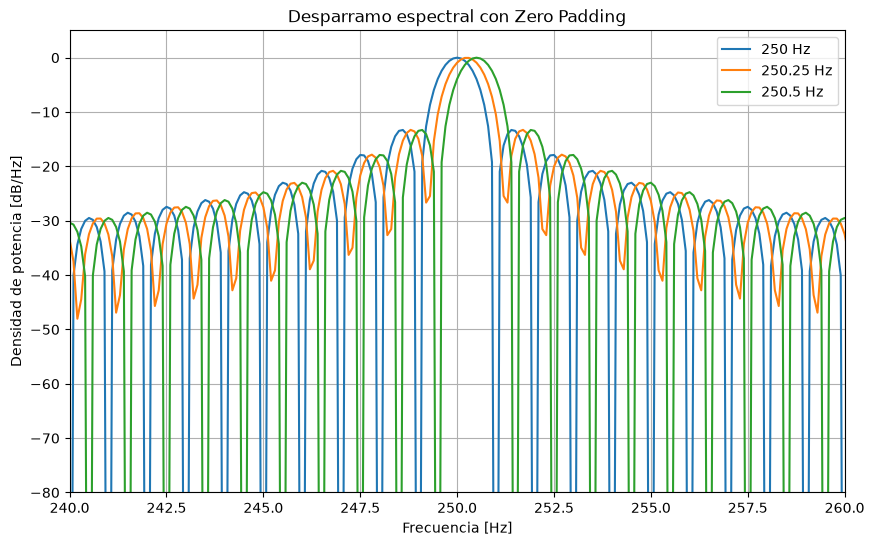

In [6]:
#%% Punto c - Zero Padding

# Nueva cantidad de puntos
Nzp = 10 * N                     # N muestras originales + 9N ceros

# Vector de ceros que vamos a agregar
ceros = np.zeros(9 * N)

# Agregamos los ceros al final de cada señal
s1_zp = np.concatenate((s1, ceros))
s2_zp = np.concatenate((s2, ceros))
s3_zp = np.concatenate((s3, ceros))


#%% FFT con zero padding

S1_zp = np.fft.rfft(s1_zp)
S2_zp = np.fft.rfft(s2_zp)
S3_zp = np.fft.rfft(s3_zp)

# Nuevo eje de frecuencias
ff_zp = np.fft.rfftfreq(Nzp, d=1/fs)

# Nueva separación entre puntos de frecuencia
df_zp = fs / Nzp

print("Delta f original =", df, "Hz")
print("Delta f con zero padding =", df_zp, "Hz")


#%% PSD

# Se mantiene N en la normalización porque las muestras reales
# siguen siendo las N originales; los demás valores son ceros.
PSD1_zp = (np.abs(S1_zp)**2) / (fs*N)
PSD2_zp = (np.abs(S2_zp)**2) / (fs*N)
PSD3_zp = (np.abs(S3_zp)**2) / (fs*N)

# Espectro unilateral
PSD1_zp[1:-1] *= 2
PSD2_zp[1:-1] *= 2
PSD3_zp[1:-1] *= 2

# Pasamos a dB
eps = 1e-20

PSD1_zp_dB = 10*np.log10(PSD1_zp + eps)
PSD2_zp_dB = 10*np.log10(PSD2_zp + eps)
PSD3_zp_dB = 10*np.log10(PSD3_zp + eps)


#%% Gráfico

plt.figure(figsize=(10,6))

plt.plot(ff_zp, PSD1_zp_dB, label='250 Hz')
plt.plot(ff_zp, PSD2_zp_dB, label='250.25 Hz')
plt.plot(ff_zp, PSD3_zp_dB, label='250.5 Hz')

plt.title('Desparramo espectral con Zero Padding')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de potencia [dB/Hz]')

# Mostramos la zona alrededor de las tres frecuencias
plt.xlim(240, 260)
plt.ylim(-80, 5)

plt.grid(True)
plt.legend()

plt.show()

Al aplicar **zero padding** se puede ver el espectro con mucho más detalle, ya que la separación entre los puntos de frecuencia pasa de 1 Hz a 0.1 Hz.

En el gráfico se distinguen mejor los máximos de las tres señales y también aparecen los lóbulos alrededor de la frecuencia principal.

Esto no significa que se haya agregado nueva información a las señales, sino que el espectro se está observando con una mayor cantidad de puntos.

También se puede ver que el desparramo sigue presente, por lo que el **zero padding** no lo elimina, solamente permite verlo con más detalle.

## Concluciones:
En esta tarea se pudo ver cómo una diferencia muy chica en la frecuencia de una senoide puede cambiar bastante la forma de su espectro.

Cuando la frecuencia coincide con un bin de la DFT, la potencia queda concentrada, mientras que al quedar entre bins aparece el desparramo espectral.

Con Parseval se comprobó que, aunque la forma del espectro cambie, la potencia total se mantiene prácticamente igual.

Por último, con zero padding se pudo observar el espectro con más detalle, aunque sin agregar información nueva ni eliminar el desparramo.